<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_3_Question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack
from scipy.signal import convolve2d
from PIL import Image
import imageio
import math

In [2]:
def rgb2gray(img):
    if img.ndim == 3:
        return np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])
    return img

def psnr(target, ref):
    mse = np.mean((target - ref) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * math.log10(PIXEL_MAX / math.sqrt(mse))

In [3]:
def motion_blur_kernel(length=15, angle=0):
    """
    Generate a linear motion blur kernel of given length and angle (degrees).
    """
    # create an empty kernel
    kernel = np.zeros((length, length))
    # center line at middle row
    kernel[length // 2, :] = 1.0
    # rotate kernel by given angle
    from scipy.ndimage import rotate
    kernel = rotate(kernel, angle, reshape=False)
    kernel /= np.sum(kernel)
    return kernel

def gaussian_kernel(size=21, sigma=5):
    """Return a 2D Gaussian kernel."""
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel /= np.sum(kernel)
    return kernel

In [4]:
def degrade_image(img, kernel, noise_sigma=10.0):
    """
    Convolve image with kernel and add Gaussian noise.
    img: 2D float image (0..255)
    kernel: 2D kernel (sums to 1)
    noise_sigma: standard deviation of additive Gaussian noise
    """
    blurred = convolve2d(img, kernel, mode='same', boundary='symm')
    noisy = blurred + np.random.normal(scale=noise_sigma, size=blurred.shape)
    noisy = np.clip(noisy, 0, 255)
    return noisy

In [5]:
def inverse_filter(degraded, kernel, eps=1e-3):
    """
    Perform inverse filtering in frequency domain: F_hat = G / H
    eps: threshold to avoid dividing by near-zero H values (stabilization)
    """
    m, n = degraded.shape
    # pad kernel to image size and center it (shifted)
    pad_k = np.zeros_like(degraded)
    kh, kw = kernel.shape
    pad_k[:kh, :kw] = kernel
    # circularly shift kernel so its center is at (0,0) in freq domain
    pad_k = np.roll(np.roll(pad_k, -kh//2, axis=0), -kw//2, axis=1)

    # FFTs
    G = fftpack.fft2(degraded)
    H = fftpack.fft2(pad_k)

    # Avoid division by small values: apply thresholding on |H|
    H_mag = np.abs(H)
    H_safe = H.copy()
    H_safe[H_mag < eps] = eps  # simple stabilization

    # Inverse filter
    F_hat = G / H_safe

    # Inverse FFT back to spatial domain
    f_hat = np.real(fftpack.ifft2(F_hat))
    f_hat = np.clip(f_hat, 0, 255)
    return f_hat

In [8]:
def main():
    # --- Load image (grayscale) ---
    # Replace with your own image file path if needed
    try:
        img = imageio.imread('/content/dog.png')
    except FileNotFoundError:
        # use a simple sample image if 'input.jpg' not found
        from scipy import misc
        img = misc.face(gray=True)  # may warn; fallback
    img = rgb2gray(img).astype(np.float64)

    # Normalize to 0..255 range (if not already)
    if img.max() <= 1.0:
        img = img * 255.0

    # --- Create blur kernel ---
    kernel = motion_blur_kernel(length=21, angle=10)  # motion blur
    # Alternatively use gaussian_kernel: kernel = gaussian_kernel(size=21, sigma=3)

    # --- Degrade image ---
    noise_sigma = 10.0
    degraded = degrade_image(img, kernel, noise_sigma=noise_sigma)

    # --- Restore using direct inverse filter ---
    eps = 1e-2  # threshold for H magnitude; tweak to control noise amplification
    restored = inverse_filter(degraded, kernel, eps=eps)

    # --- PSNR metrics ---
    psnr_degraded = psnr(degraded, img)
    psnr_restored = psnr(restored, img)

    # --- Show results ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title('Original')
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)

    plt.subplot(1, 3, 2)
    plt.title(f'Degraded\nPSNR={psnr_degraded:.2f} dB')
    plt.axis('off')
    plt.imshow(degraded, cmap='gray', vmin=0, vmax=255)

    plt.subplot(1, 3, 3)
    plt.title(f'Restored (Inverse)\nPSNR={psnr_restored:.2f} dB')
    plt.axis('off')
    plt.imshow(restored, cmap='gray', vmin=0, vmax=255)

    plt.tight_layout()
    plt.show()

    # Save outputs (optional)
    imageio.imwrite('degraded.png', degraded.astype(np.uint8))
    imageio.imwrite('restored_inverse.png', restored.astype(np.uint8))
    print(f"Saved degraded.png and restored_inverse.png. PSNR degraded={psnr_degraded:.2f}, restored={psnr_restored:.2f}")

/tmp/ipython-input-909445391.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('/content/dog.png')


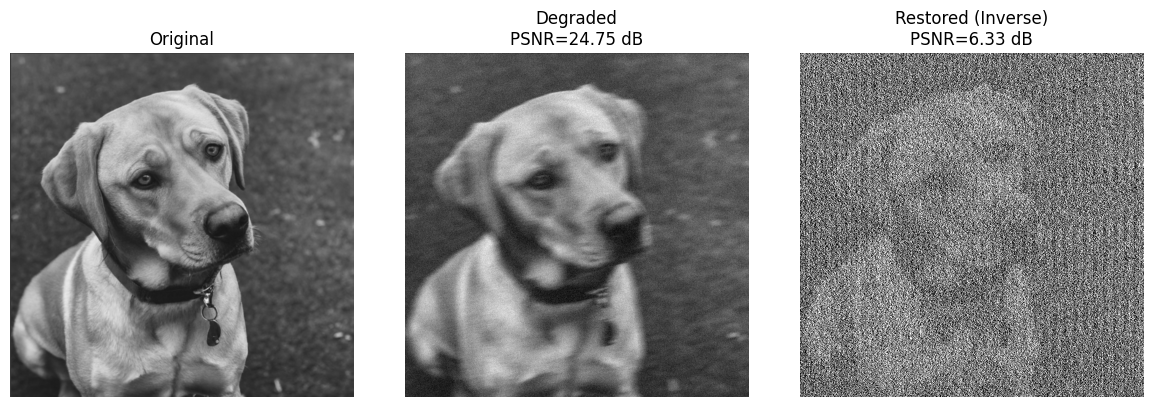

Saved degraded.png and restored_inverse.png. PSNR degraded=24.75, restored=6.33


In [9]:
if __name__ == "__main__":
    main()